# Using pretrained atomistic models as representations

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/adv_atomistic_mace.ipynb)

**Prerequisites**

- Basic familiarity with graph-based CVs in `mlcolvar`
- Basic familiarity with training a neural-network CV

**Author:** Kai Zhu

## Overview

Pretrained atomistic models can provide expressive molecular representations
that are reused for downstream collective-variable tasks.

In this tutorial, we use a pretrained MACE model as a frozen representation
and train a DeepTDA CV on top of its latent features:

```text
atomic configuration
        ↓
pretrained MACE model
        ↓
MACERepresentation
        ↓
system-level representation h(R)
        ↓
task-specific FeedForward head
        ↓
DeepTDA CV
```

The representation and the downstream CV are deliberately kept separate.
Because the atomistic representation is frozen, its features can be
precomputed once during training. For inference or enhanced sampling, the
representation is attached to the trained CV as `preprocessing`, restoring a
model that operates directly on atomic configurations.

```text
training:    graph → frozen representation → precomputed h(R) → train CV head
deployment:  graph → frozen representation → trained CV head → CV
```

If an adapter for an atomistic model does not yet exist, see the companion
tutorial **Wrapping custom atomistic models as representations**.


## 1. Load a pretrained atomistic model

We use MACE as an example of a pretrained atomistic model.
`MACERepresentation` adapts the MACE backbone to the common
`Representation` interface used by `mlcolvar`. Since MACE consumes atomistic
graphs, the adapter internally uses `input_kind="graph"`.

Two options are important here:

- `freeze=True` keeps the pretrained model parameters fixed. Gradients with
  respect to atomic coordinates can still be computed when needed.
- `pooling_operation="mean"` converts atom-level latent features into one
  system-level vector for each molecular configuration.

The first call to `mace_mp` may download the pretrained model weights.
The resulting `representation.out_features` is the input dimension of the
downstream task-specific head.


In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

import torch

if importlib.util.find_spec("mace") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "mace-torch"]
    )
if importlib.util.find_spec("metatomic") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "metatomic-torch"]
    )

from mace.calculators import mace_mp
from mlcolvar.representation import (
    MACERepresentation,
    SelectAtoms,
    evaluate_dataset,
)

torch.manual_seed(41)
torch.set_default_dtype(torch.float32)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("./data/alanine_gnn")

calculator = mace_mp(
    model="small",
    device=DEVICE,
    default_dtype="float32",
)
representation = MACERepresentation(
    model=calculator.models[0].eval(),
    pooling_operation="mean",
    freeze=True,
)

print("Feature dimension:", representation.out_features)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Materials Project MACE for MACECalculator with /home/kzhu-iit.local/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Feature dimension: 256


## 2. Build a compatible graph dataset

The pretrained model expects atomistic graph inputs rather than precomputed
descriptors. `DictDataset.graph_from_trajectories` converts molecular
trajectories into the graph format used by `mlcolvar`.

Graph construction must remain consistent with the pretrained representation:

- `cutoff` is taken directly from the pretrained model;
- MDTraj coordinates are in nm whereas MACE uses Å, so
  `lengths_conversion=10.0`;
- `representation.align_dataset(dataset)` aligns `node_attrs` with the atomic
  species ordering expected by the pretrained model.

After this step, the graph dataset can be passed directly to the representation.


In [2]:
from mlcolvar.data import DictDataset

dataset = DictDataset.graph_from_trajectories(
    trajectories=["alad_A.trr", "alad_B.trr"],
    topologies="alad.gro",
    folder=str(DATA_DIR),
    cutoff=float(representation.cutoff.detach().cpu()),
    system_selection="all",
    show_progress=False,
    load_args=[
        {"start": 0, "stop": 10000, "stride": 5},
        {"start": 0, "stop": 10000, "stride": 5},
    ],
    lengths_conversion=10.0,
)
dataset = representation.align_dataset(dataset)
print(dataset)


/home/kzhu-iit.local/data/mlcolvar/mlcolvar/data/graph/utils.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94],
		      "cutoff": 6.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
		      "system_atoms_names": [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME3-N, NME3-H, NME3-C, NME3-H1, NME3-H2, NME3-H3],
		      "is_truncated_graph": False,
		      "data_type": graphs } )


### Selecting specific atom features

The representation above uses mean pooling to obtain one system-level feature
vector for each configuration. Alternatively, setting
`pooling_operation=None` returns atom-level latent features.

For systems with a consistent atom ordering, such as molecular dynamics
trajectories with a fixed topology, `SelectAtoms` can select specific atoms
and concatenate their latent features into a system-level representation:

```text
graph
  ↓
MACERepresentation(pooling_operation=None)
  ↓
atom-level features
  ↓
SelectAtoms
  ↓
selected system-level features
```

This can be useful when only a subset of atoms is relevant for the downstream
task. The selected indices must have the same physical meaning across systems.


In [3]:
from torch_geometric.loader import DataLoader as GraphDataLoader

atom_representation = MACERepresentation(
    model=calculator.models[0].eval(),
    pooling_operation=None,
    freeze=True,
).to(DEVICE)

selector = SelectAtoms([0, 1])

loader = GraphDataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
)
batch = next(iter(loader))["data_list"].to(DEVICE)

with torch.no_grad():
    atom_features = atom_representation(batch)
    selected_features = selector(atom_features, batch.ptr)

print("Atom-level features :", tuple(atom_features.shape))
print("Selected features   :", tuple(selected_features.shape))


Atom-level features : (88, 256)
Selected features   : (4, 512)


## 3. Precompute the frozen representation

If the frozen MACE model were evaluated inside every training step, each batch
would repeatedly execute the expensive atomistic backbone:

```text
graph → MACERepresentation → task-specific head → DeepTDA loss
```

Since the representation parameters are fixed, its output does not change
during training. We can therefore evaluate it once over the dataset:

```text
graph → MACERepresentation → h(R)   # computed once
```

and optimize only the downstream model:

```text
precomputed h(R) → task-specific head → DeepTDA loss
```

`evaluate_dataset(representation, dataset)` performs this batched evaluation
and returns the system-level representations as an ordinary tensor.

DeepTDA does not require coordinate derivatives in its training loss, so only
the representation values are required here; no coordinate Jacobian needs to
be precomputed.


In [4]:
features = evaluate_dataset(
    representation,
    dataset,
    device=DEVICE,
)
labels = torch.cat(
    [graph.graph_labels.reshape(-1) for graph in dataset["data_list"]]
)

feature_dataset = DictDataset(
    {
        "data": features,
        "labels": labels,
    }
)

print("Feature shape:", tuple(features.shape))


Feature shape: (4000, 256)


## 4. Train the downstream CV

Once the representation has been precomputed, training proceeds exactly as for
any descriptor-based CV. The downstream `FeedForward` model takes
`representation.out_features` inputs and is optimized with the DeepTDA
objective.


In [ ]:
from lightning import Trainer

from mlcolvar.core import FeedForward
from mlcolvar.cvs import DeepTDA
from mlcolvar.data import DictModule
from mlcolvar.utils.trainer import MetricsCallback

datamodule = DictModule(
    feature_dataset,
    batch_size=128,
    lengths=[0.8, 0.2],
)

head = FeedForward([representation.out_features, 32, 32, 1])
model = DeepTDA(
    n_states=2,
    n_cvs=1,
    target_centers=[-7.0, 7.0],
    target_sigmas=[0.2, 0.2],
    model=head,
)

# record training metrics
metrics = MetricsCallback()

trainer = Trainer(
    callbacks=[metrics],
    max_epochs=5,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
)

trainer.fit(model, datamodule)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 99: 100%|██████████| 25/25 [00:00<00:00, 175.28it/s]                 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 25/25 [00:00<00:00, 174.27it/s]


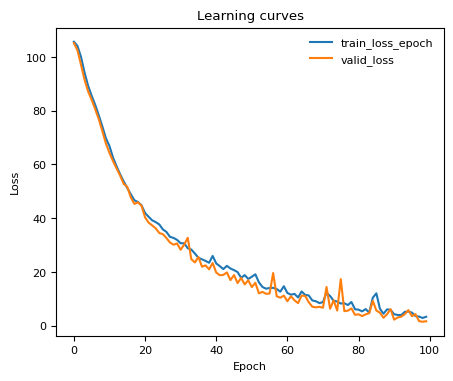

In [6]:
from mlcolvar.utils.plot import plot_metrics
# plot training and validation loss
ax = plot_metrics(
    metrics.metrics,
    keys=["train_loss_epoch", "valid_loss"],
)

## 5. Evaluate the learned CV

A simple way to inspect the trained CV is to compare its values for the two
input states. The goal here is not to benchmark MACE or DeepTDA, but to verify
that the pretrained representation can be used as input to a downstream CV.


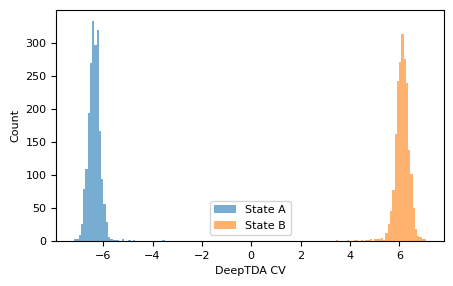

In [7]:
import matplotlib.pyplot as plt

model = model.to(DEVICE).eval()

with torch.no_grad():
    cv_values = model(features.to(DEVICE)).reshape(-1).cpu()

labels_cpu = labels.reshape(-1).cpu()

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(
    cv_values[labels_cpu == 0].numpy(),
    bins=40,
    alpha=0.6,
    label="State A",
)
ax.hist(
    cv_values[labels_cpu == 1].numpy(),
    bins=40,
    alpha=0.6,
    label="State B",
)
ax.set_xlabel("DeepTDA CV")
ax.set_ylabel("Count")
ax.legend()
plt.show()


## 6. Restore raw-graph inference

Training above used precomputed representations. For molecular simulation, the
CV should instead accept the original atomistic graph input. The unified
`Representation` API keeps this distinction through `input_kind="graph"`.

`BaseCV.preprocessing` provides this composition directly:

```text
raw graph
   ↓
preprocessing = MACERepresentation
   ↓
trained DeepTDA head
   ↓
CV
```

The trained DeepTDA model is copied and the frozen representation is attached
as `preprocessing`. The precomputed training features are not required for
inference or deployment.


In [8]:
import copy

raw_model = copy.deepcopy(model).eval()
raw_model.preprocessing = representation


## 7. Verify the two inference paths

The precomputed-feature and raw-input paths should be numerically equivalent:

```text
raw graph → representation → trained head
h(R)                    → trained head
```

This check verifies that representation evaluation, pooling, atom ordering, and
feature layout are consistent with the final raw-input model.


In [9]:
raw_model = raw_model.to(DEVICE).eval()
model = model.to(DEVICE).eval()

raw_cv = evaluate_dataset(
    raw_model,
    dataset,
    batch_size=256,
    device=DEVICE,
).reshape(-1)

with torch.no_grad():
    precomputed_cv = (
        model(features.to(DEVICE))
        .reshape(-1)
        .cpu()
    )

torch.testing.assert_close(
    raw_cv,
    precomputed_cv,
    rtol=1e-4,
    atol=1e-5,
)

print("Precomputed and raw-input predictions agree.")


Precomputed and raw-input predictions agree.


## 8. Export the model for molecular simulations

Deployment must use the raw-input model rather than the model trained on
precomputed features, because a simulation engine provides atomic
configurations rather than latent representations.

The exported model therefore contains both components:

```text
atomic configuration
        ↓
frozen MACERepresentation
        ↓
trained DeepTDA head
        ↓
CV
```

`export_metatomic_model` converts the complete raw-input model to the
Metatomic interface for use in supported molecular-simulation workflows.


In [10]:
from mlcolvar.metatomic import export_metatomic_model

raw_model = raw_model.cpu().eval()
export_path = Path("deep_tda_mace_metatomic.pt")

export_metatomic_model(
    raw_model,
    export_path,
    supported_devices=["cpu"],
)

print("Saved model:", export_path.resolve())


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Saved model: /home/kzhu-iit.local/data/mlcolvar/docs/notebooks/tutorials/deep_tda_mace_metatomic.pt


### PLUMED example

The exported model can be evaluated from PLUMED through `METATOMIC`.
The species mapping must be consistent with the atomic types expected by the
pretrained representation.

```plumed
cv: METATOMIC ...
    MODEL=./deep_tda_mace_metatomic.pt
    DEVICE=cpu
    SPECIES1=h
    SPECIES2=c
    SPECIES3=n
    SPECIES4=o
    SPECIES_TO_TYPES=1,6,7,8
...

opes: OPES_METAD ...
    ARG=cv.node-0
    PACE=500
    TEMP=300
    BARRIER=40
...

PRINT ARG=cv.node-0,opes.* FILE=COLVAR STRIDE=500
```
